# Probleme 1: Approximation gaussienne d’une loi de Poisson

#### On importe les bibliothèques nécessaires

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

#### Etude de la suite de fonctions gn, qui va permettre de montrer l'intérêt de se limiter à [-3, 3]

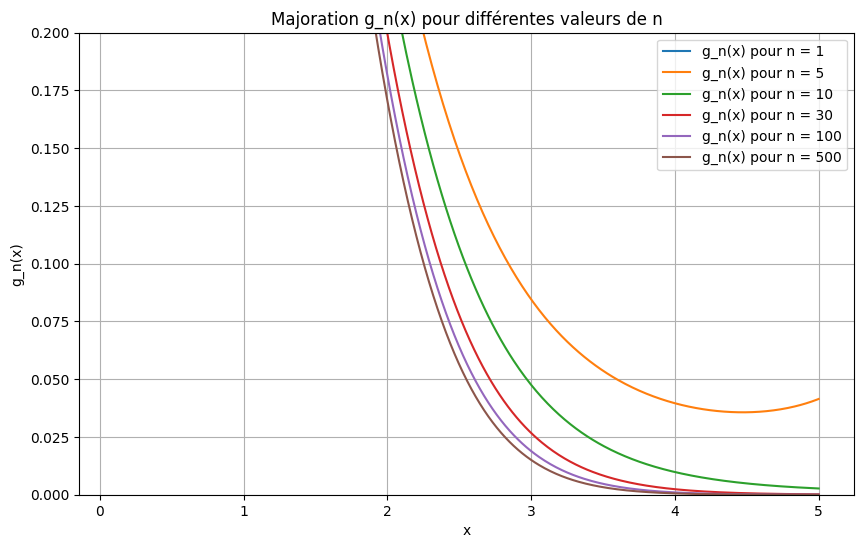

In [3]:
# Paramètres
n_values = [1, 5, 10, 30, 100, 500]
x = np.linspace(0.1, 5, 500)  # on évite 0 à cause du 1/x

def g_n(x, n):
    term1 = (1 / (x * np.sqrt(2 * np.pi))) * np.exp(-x**2 / 2)
    term2 = np.exp(-x**2 / 2 + x**3 / (6 * np.sqrt(n)))
    return term1 + term2

plt.figure(figsize=(10, 6))
for n in n_values:
    plt.plot(x, g_n(x, n), label=f'g_n(x) pour n = {n}')

plt.ylim(0, 0.2)  
plt.xlabel('x')
plt.ylabel('g_n(x)')
plt.title('Majoration g_n(x) pour différentes valeurs de n')
plt.legend()
plt.grid(True)
plt.show()

#### J'ai choisi quand même de vérifier que la vraie différence était valable

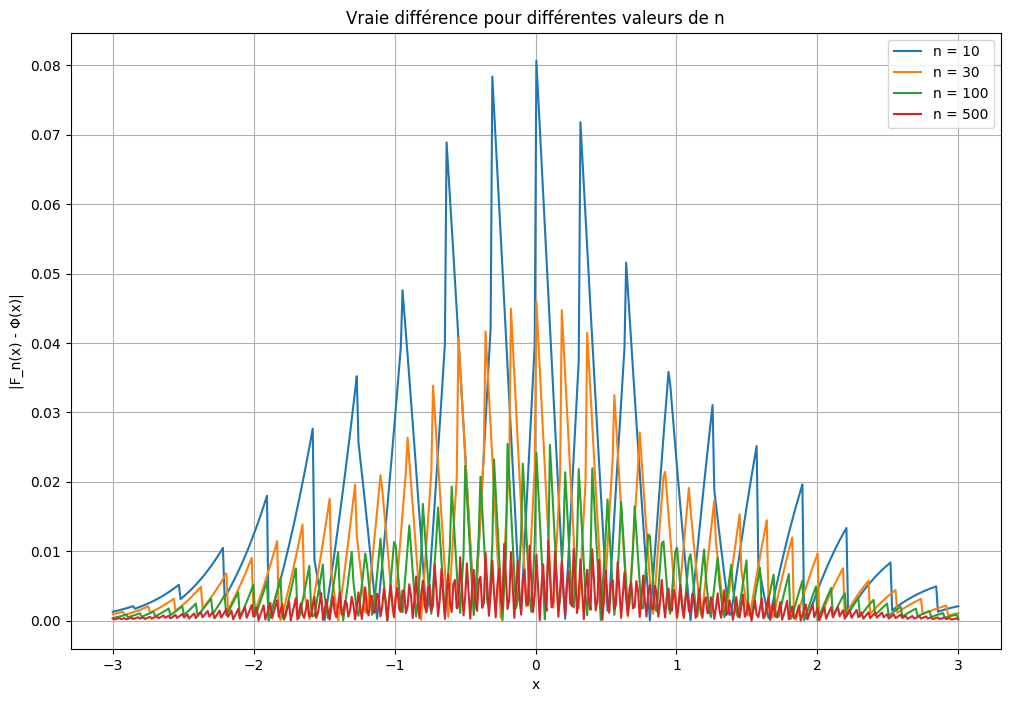

In [4]:
# Calcul de la vraie différence |F_n(x) - Φ(x)|
def true_diff(n, x):
    # Pour chaque x, on calcule F_n(x) = P(P_n ≤ floor(n + x√n))
    k = np.floor(n + x * np.sqrt(n)).astype(int)
    k = np.maximum(k, 0)
    F_n = poisson.cdf(k, n)
    Phi = norm.cdf(x)
    return np.abs(F_n - Phi)

# Tracé pour quelques n
x_fine = np.linspace(-3, 3, 500)
plt.figure(figsize=(12, 8))
for n in [10, 30, 100, 500]:
    diff = [true_diff(n, xi) for xi in x_fine]
    plt.plot(x_fine, diff, label=f'n = {n}')

plt.xlabel('x')
plt.ylabel('|F_n(x) - Φ(x)|')
plt.title('Vraie différence pour différentes valeurs de n')
plt.legend()
plt.grid(True)
plt.show()

#### Etude de la complexité ie le nombre de calculs élémentaires pour calculer alpha_n

n =   10 : alpha ≈ 0.06622, ops = 315, temps = 0.003s
n =   20 : alpha ≈ 0.03847, ops = 1230, temps = 0.006s
n =   50 : alpha ≈ 0.03004, ops = 7575, temps = 0.015s
n =  100 : alpha ≈ 0.02292, ops = 30156, temps = 0.029s
n =  200 : alpha ≈ 0.01681, ops = 120300, temps = 0.048s
n =  500 : alpha ≈ 0.01150, ops = 750750, temps = 0.215s
n = 1000 : alpha ≈ 0.99865, ops = 3001500, temps = 0.741s


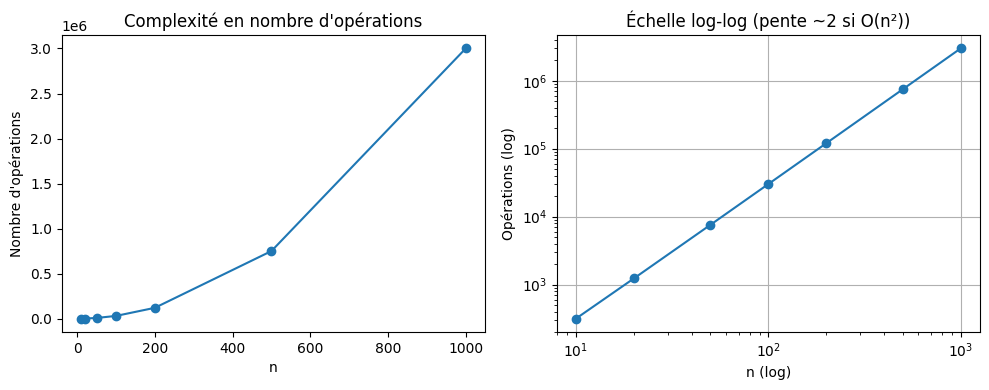

In [5]:
import time

def poisson_cdf_naive(k, n):
    """
    Calcule P(P_n <= k) par somme directe avec récurrence.
    Retourne aussi le nombre d'opérations (additions + multiplications).
    """
    if k < 0:
        return 0.0, 0
    ops = 0
    p = np.exp(-n)          # p0 = e^{-n}
    ops += 1  # exponentielle (comptée comme 1 opération élémentaire)
    cumul = p
    ops += 1  # addition
    for i in range(1, k+1):
        p = p * (n / i)     # multiplication + division (comptée comme 2 ops)
        ops += 2
        cumul += p
        ops += 1  # addition
    return cumul, ops

def alpha_n_complexity(n, n_points=100):
    """
    Calcule alpha_n avec une grille de n_points points dans [-3,3].
    Retourne alpha_n et le nombre total d'opérations.
    """
    x_vals = np.linspace(-3, 3, n_points)
    total_ops = 0
    max_diff = 0.0
    
    for x in x_vals:
        k = int(np.floor(n + x * np.sqrt(n)))
        if k < 0:
            F_n = 0.0
            ops_k = 0
        else:
            F_n, ops_k = poisson_cdf_naive(k, n)
        total_ops += ops_k
        Phi = norm.cdf(x)   # considéré comme 1 opération élémentaire (bibliothèque)
        total_ops += 1
        diff = abs(F_n - Phi)
        if diff > max_diff:
            max_diff = diff
    return max_diff, total_ops

# Test pour différentes valeurs de n
n_list = [10, 20, 50, 100, 200, 500, 1000]
times = []
ops_list = []

for n in n_list:
    start = time.time()
    alpha, ops = alpha_n_complexity(n, n_points=n)  # n_points = n pour avoir O(n²)
    elapsed = time.time() - start
    ops_list.append(ops)
    times.append(elapsed)
    print(f"n = {n:4d} : alpha ≈ {alpha:.5f}, ops = {ops}, temps = {elapsed:.3f}s")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(n_list, ops_list, 'o-')
plt.xlabel('n')
plt.ylabel('Nombre d\'opérations')
plt.title('Complexité en nombre d\'opérations')

plt.subplot(1,2,2)
plt.loglog(n_list, ops_list, 'o-')
plt.xlabel('n (log)')
plt.ylabel('Opérations (log)')
plt.title('Échelle log-log (pente ~2 si O(n²))')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Etude de la vitesse de convergence de alpha_n

Calcul de alpha_n en cours...
n =   10 : alpha_n = 0.082441
n =   20 : alpha_n = 0.058494
n =   50 : alpha_n = 0.036918
n =  100 : alpha_n = 0.025982
n =  200 : alpha_n = 0.018713
n =  500 : alpha_n = 0.011551
n = 1000 : alpha_n = 0.008366


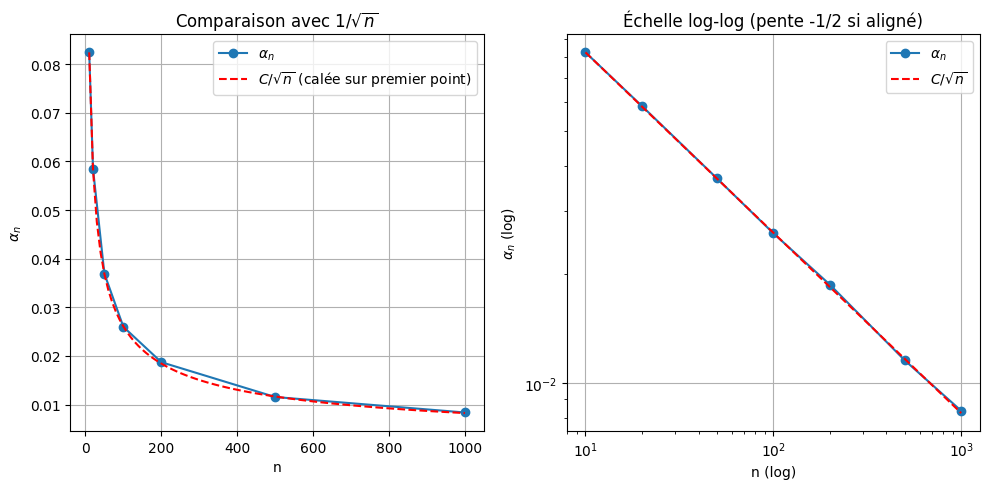


Rapport alpha_n * sqrt(n) :
n =   10 : alpha_n * sqrt(n) = 0.2607
n =   20 : alpha_n * sqrt(n) = 0.2616
n =   50 : alpha_n * sqrt(n) = 0.2610
n =  100 : alpha_n * sqrt(n) = 0.2598
n =  200 : alpha_n * sqrt(n) = 0.2646
n =  500 : alpha_n * sqrt(n) = 0.2583
n = 1000 : alpha_n * sqrt(n) = 0.2645


In [6]:
def true_alpha_n(n, n_points=1000):
    """
    Calcule alpha_n = sup_x |F_n(x) - Phi(x)|
    avec une grille de n_points points dans [-3, 3]
    """
    x_vals = np.linspace(-3, 3, n_points)
    max_diff = 0.0
    for x in x_vals:
        k = int(np.floor(n + x * np.sqrt(n)))
        if k < 0:
            F_n = 0.0
        else:
            F_n = poisson.cdf(k, n)
        Phi = norm.cdf(x)
        diff = abs(F_n - Phi)
        if diff > max_diff:
            max_diff = diff
    return max_diff

# Valeurs de n à tester
n_list = [10, 20, 50, 100, 200, 500, 1000]
alpha_list = []

print("Calcul de alpha_n en cours...")
for n in n_list:
    alpha = true_alpha_n(n, n_points=2000)  # grille fine pour bonne précision
    alpha_list.append(alpha)
    print(f"n = {n:4d} : alpha_n = {alpha:.6f}")

plt.figure(figsize=(10, 5))

# Echelle linéaire
plt.subplot(1, 2, 1)
plt.plot(n_list, alpha_list, 'o-', label=r'$\alpha_n$')

# Tracer C/√n pour comparer
n_range = np.linspace(min(n_list), max(n_list), 100)
C = alpha_list[0] * np.sqrt(n_list[0])  # ajustement sur la première valeur
plt.plot(n_range, C / np.sqrt(n_range), 'r--', label=r'$C / \sqrt{n}$ (calée sur premier point)')
plt.xlabel('n')
plt.ylabel(r'$\alpha_n$')
plt.title('Comparaison avec $1/\sqrt{n}$')
plt.legend()
plt.grid(True)

# Echelle log-log
plt.subplot(1, 2, 2)
plt.loglog(n_list, alpha_list, 'o-', label=r'$\alpha_n$')
plt.loglog(n_range, C / np.sqrt(n_range), 'r--', label=r'$C / \sqrt{n}$')
plt.xlabel('n (log)')
plt.ylabel(r'$\alpha_n$ (log)')
plt.title('Échelle log-log (pente -1/2 si aligné)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nRapport alpha_n * sqrt(n) :")
for n, alpha in zip(n_list, alpha_list):
    print(f"n = {n:4d} : alpha_n * sqrt(n) = {alpha * np.sqrt(n):.4f}")

In [7]:
import warnings
warnings.filterwarnings('ignore')

def compute_alpha(n, K, n_points=200):
    """
    Calcule alpha_{n,K} par simulation.
    n : paramètre de Poisson
    K : nombre d'échantillons
    n_points : nombre de points x pour le sup
    """
    X = np.random.poisson(n, size=K) # Génération des données : K échantillons de Poisson(n)
    Z = (X - n) / np.sqrt(n) # Standardisation
    x_vals = np.linspace(-4, 4, n_points) # Points x où évaluer la fonction de répartition
    ecdf = np.array([np.mean(Z <= x) for x in x_vals])     # Fonction de répartition empirique
    normal_cdf = norm.cdf(x_vals) # Vraie loi normale
    alpha = np.max(np.abs(ecdf - normal_cdf))# Erreur maximale
    
    return alpha

In [8]:
# Paramètres
n_values = [10, 50, 100, 200, 400, 800, 1600]
K_choices = {
    "K = n": lambda n: n,
    "K = n^1.5": lambda n: int(n**1.5),
    "K = n^2": lambda n: n**2
}

# Stockage des résultats
results = {label: [] for label in K_choices}

# Simulation
n_replicates = 30  # pour estimer la moyenne

for n in tqdm(n_values, desc="n values"):
    for label, K_func in K_choices.items():
        K = K_func(n)
        alphas = []
        for _ in range(n_replicates):
            alpha = compute_alpha(n, K)
            alphas.append(alpha)
        results[label].append(np.mean(alphas))

NameError: name 'tqdm' is not defined

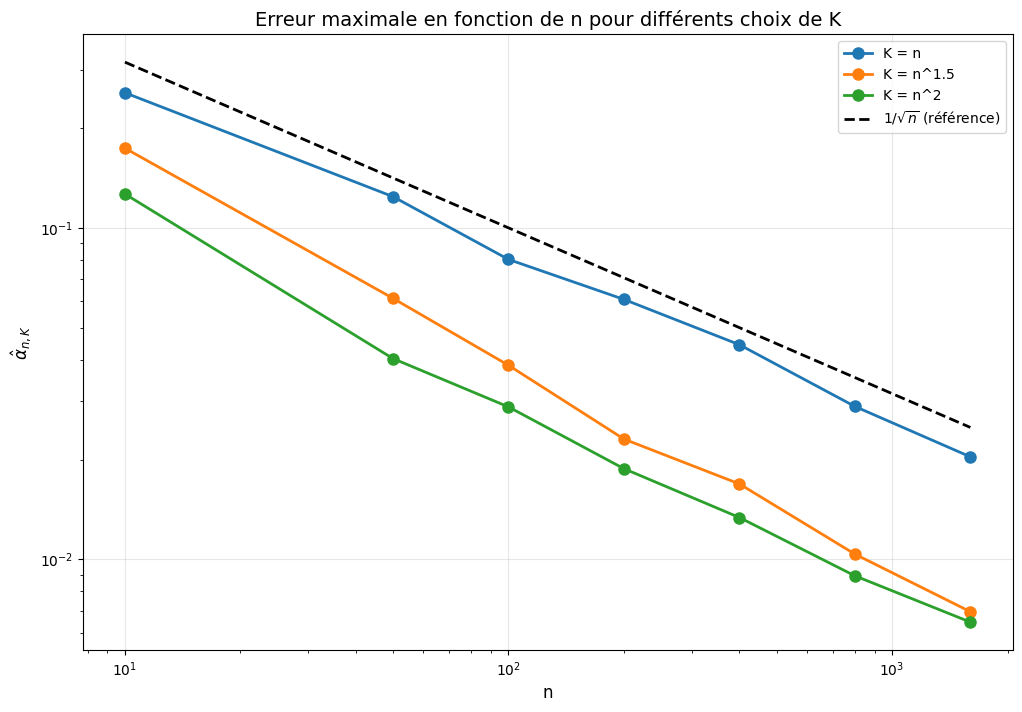

In [18]:
plt.figure(figsize=(12, 8))

n_array = np.array(n_values)
ref = 1.0 / np.sqrt(n_array)  # référence en 1/sqrt(n)

for label, alphas in results.items():
    plt.loglog(n_array, alphas, 'o-', label=label, linewidth=2, markersize=8)

plt.loglog(n_array, ref, 'k--', label=r'$1/\sqrt{n}$ (référence)', linewidth=2)
plt.xlabel('n', fontsize=12)
plt.ylabel(r'$\hat{\alpha}_{n,K}$', fontsize=12)
plt.title('Erreur maximale en fonction de n pour différents choix de K', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

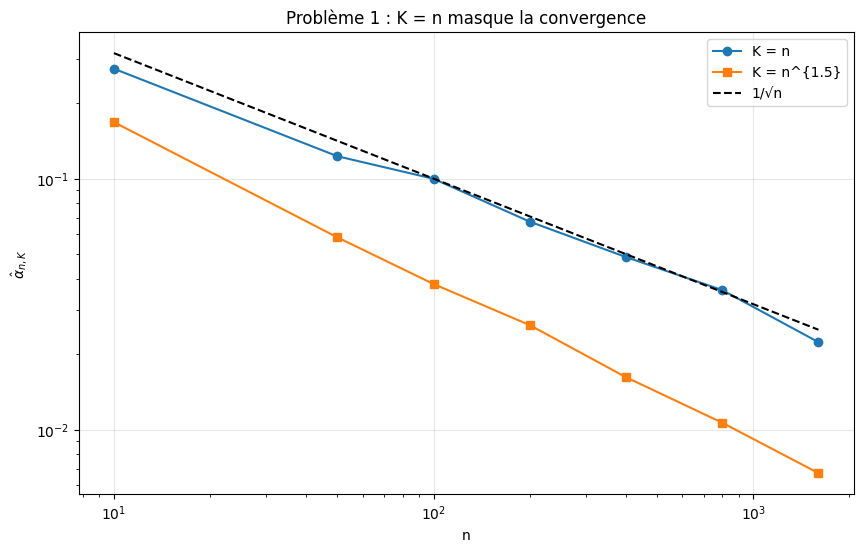

In [9]:
# Problème 1 : Choix de K_n trop petit (K = n)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def compute_alpha(n, K, n_points=200):
    X = np.random.poisson(n, size=K)
    Z = (X - n) / np.sqrt(n)
    x_vals = np.linspace(-3, 3, n_points)
    ecdf = np.array([np.mean(Z <= x) for x in x_vals])
    normal_cdf = norm.cdf(x_vals)
    return np.max(np.abs(ecdf - normal_cdf))

n_values = [10, 50, 100, 200, 400, 800, 1600]
n_replicates = 30

# K = n
alphas_n = []
for n in n_values:
    K = n
    alphas = [compute_alpha(n, K) for _ in range(n_replicates)]
    alphas_n.append(np.mean(alphas))

# K = n^1.5
alphas_n15 = []
for n in n_values:
    K = int(n**1.5)
    alphas = [compute_alpha(n, K) for _ in range(n_replicates)]
    alphas_n15.append(np.mean(alphas))

plt.figure(figsize=(10, 6))
plt.loglog(n_values, alphas_n, 'o-', label='K = n')
plt.loglog(n_values, alphas_n15, 's-', label='K = n^{1.5}')
plt.loglog(n_values, 1/np.sqrt(n_values), 'k--', label='1/√n')
plt.xlabel('n')
plt.ylabel(r'$\hat{\alpha}_{n,K}$')
plt.title('Problème 1 : K = n masque la convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Problème 2 : Coût de calcul prohibitif
import time

def estimate_time(n, K, n_replicates=5):
    start = time.time()
    for _ in range(n_replicates):
        _ = compute_alpha(n, K)
    return (time.time() - start) / n_replicates

n_test = 1000
K_values = [n_test, int(n_test**1.5), n_test**2]

print(f"Pour n = {n_test}:")
for K in K_values:
    if K > 1e6:
        print(f"  K = {K:,} → trop coûteux à calculer")
    else:
        t = estimate_time(n_test, K)
        print(f"  K = {K:,} → {t:.3f} secondes par simulation")

Pour n = 1000:
  K = 1,000 → 0.007 secondes par simulation
  K = 31,622 → 0.024 secondes par simulation
  K = 1,000,000 → 0.659 secondes par simulation


Pour n = 200:
  K = 10n = 2000: moyenne = 0.0271, std = 0.0062
  K = 100n = 20000: moyenne = 0.0179, std = 0.0027


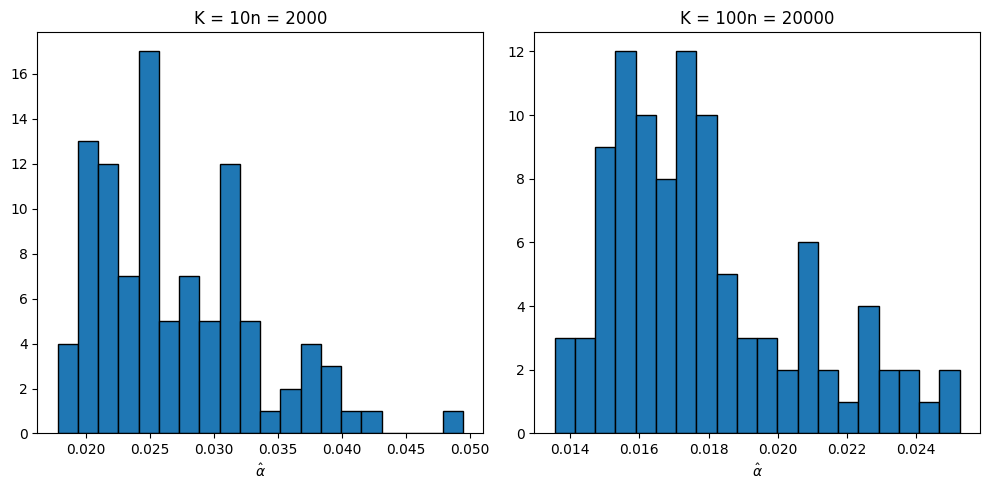

In [11]:
# Problème 3 : Variance de l'estimateur
n_var = 200
K_moderate = n_var * 10
K_large = n_var * 100

alphas_moderate = [compute_alpha(n_var, K_moderate) for _ in range(100)]
alphas_large = [compute_alpha(n_var, K_large) for _ in range(100)]

print(f"Pour n = {n_var}:")
print(f"  K = 10n = {K_moderate}: moyenne = {np.mean(alphas_moderate):.4f}, std = {np.std(alphas_moderate):.4f}")
print(f"  K = 100n = {K_large}: moyenne = {np.mean(alphas_large):.4f}, std = {np.std(alphas_large):.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.hist(alphas_moderate, bins=20, edgecolor='black')
plt.xlabel(r'$\hat{\alpha}$')
plt.title(f'K = 10n = {K_moderate}')
plt.subplot(1,2,2)
plt.hist(alphas_large, bins=20, edgecolor='black')
plt.xlabel(r'$\hat{\alpha}$')
plt.title(f'K = 100n = {K_large}')
plt.tight_layout()
plt.show()

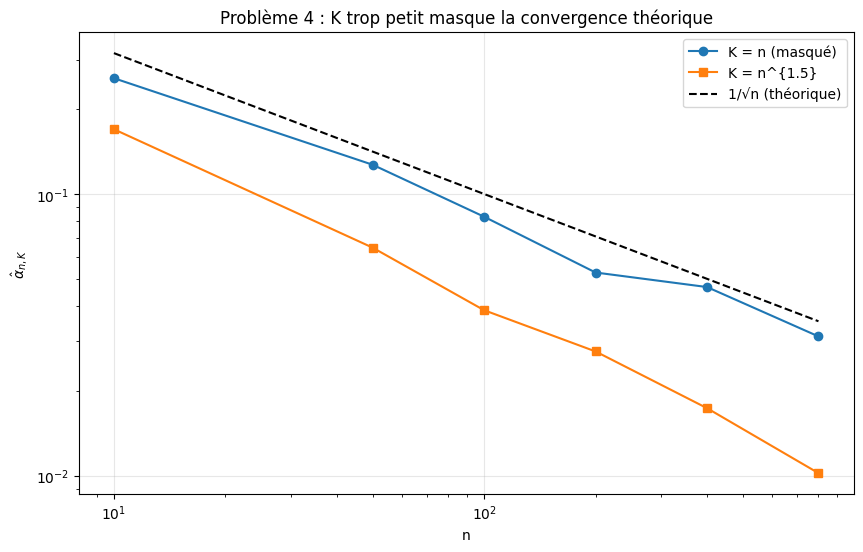

In [12]:
# Problème 4 : Masquage de l'erreur théorique
n_values_problem4 = [10, 50, 100, 200, 400, 800]
K_small = lambda n: n
K_large = lambda n: int(n**1.5)

alphas_small = []
alphas_large = []
theoretical = []

for n in n_values_problem4:
    alphas_small.append(np.mean([compute_alpha(n, K_small(n)) for _ in range(20)]))
    alphas_large.append(np.mean([compute_alpha(n, K_large(n)) for _ in range(20)]))
    theoretical.append(1/np.sqrt(n))

plt.figure(figsize=(10, 6))
plt.loglog(n_values_problem4, alphas_small, 'o-', label='K = n (masqué)')
plt.loglog(n_values_problem4, alphas_large, 's-', label='K = n^{1.5}')
plt.loglog(n_values_problem4, theoretical, 'k--', label='1/√n (théorique)')
plt.xlabel('n')
plt.ylabel(r'$\hat{\alpha}_{n,K}$')
plt.title('Problème 4 : K trop petit masque la convergence théorique')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()